In [ ]:
import random
from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, metrics, models, optimizers, activations, losses

import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torchvision.datasets as dsets
from torchvision.datasets import GTSRB

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.11.0
CUDA available: False


In [40]:
RAW_DIR       = "./data/raw"        # Where raw GTSRB data is downloaded
PROCESSED_DIR = "./data/processed"  # Where cleaned images are saved
IMAGE_SIZE      = 64                  # Output resolution (64 or 128 recommended)
MAX_PER_CLASS = 10                 # Max images sampled per sign class
BATCH_SIZE    = 64                  # DataLoader batch size
SEED          = 42                  # Reproducibility
DATASET_REPETITIONS = 1
EPOCHS = 1
EMA = 0.999
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NOISE_EMBEDDING_SIZE = 32

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [41]:
train_dataset = GTSRB(root=RAW_DIR, split="train", download=True)

sample_indices = random.sample(range(len(train_dataset)), 200)

def preprocess_gtsrb_image(pil_img):
    img = pil_img.convert("RGB")
    img = ImageOps.fit(
        img,
        (IMAGE_SIZE, IMAGE_SIZE),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    return np.asarray(img, dtype=np.float32) / 255.0

sampled_images = []
for idx in sample_indices:
    pil_img, _ = train_dataset[idx]
    sampled_images.append(preprocess_gtsrb_image(pil_img))

sampled_images = np.stack(sampled_images, axis=0)

train = tf.data.Dataset.from_tensor_slices(sampled_images)
train = train.shuffle(200, seed=SEED)
train = train.batch(BATCH_SIZE, drop_remainder=False)
train = train.prefetch(tf.data.AUTOTUNE)
train = train.repeat(DATASET_REPETITIONS)

In [42]:
def offset_cosine_diffusion_schedule(diffusion_times):
    min_signal_rate = 0.02
    max_signal_rate = 0.95
    start_angle = tf.acos(max_signal_rate)
    end_angle = tf.acos(min_signal_rate)

    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

    signal_rates = tf.cos(diffusion_angles)
    noise_rates = tf.sin(diffusion_angles)

    return noise_rates, signal_rates

In [43]:
@tf.keras.utils.register_keras_serializable()
def sinusoidal_embedding(x):
    frequencies = tf.exp(tf.linspace( tf.math.log(1.0), tf.math.log(1000.0), NOISE_EMBEDDING_SIZE // 2))
    angular_speeds = 2.0 * math.pi * frequencies
    embeddings = tf.concat([tf.sin(angular_speeds * x), tf.cos(angular_speeds * x)], axis=3)
    return embeddings

def ResidualBlock(width):
    def apply(x):
        input_width = x.shape[3]
        if input_width == width:
            residual = x
        else:
            residual = layers.Conv2D(width, kernel_size=1)(x)
        x = layers.BatchNormalization(center=False, scale=False)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", activation=activations.swish)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
        x = layers.Add()([x, residual])
        return x

    return apply

def DownBlock(width, block_depth):
    def apply(x):
        x, skips = x
        for _ in range(block_depth):
            x = ResidualBlock(width)(x)
            skips.append(x)
        x = layers.AveragePooling2D(pool_size=2)(x)
        return x

    return apply

def UpBlock(width, block_depth):
    def apply(x):
        x, skips = x
        x = layers.UpSampling2D(size=2, interpolation="bilinear")(x)
        for _ in range(block_depth):
            x = layers.Concatenate()([x, skips.pop()])
            x = ResidualBlock(width)(x)
        return x
    return apply

In [44]:
noisy_images = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Conv2D(32, kernel_size=1)(noisy_images)

noise_variances = layers.Input(shape=(1, 1, 1))
noise_embedding = layers.Lambda(sinusoidal_embedding, output_shape=(1, 1, NOISE_EMBEDDING_SIZE))(noise_variances)
noise_embedding = layers.UpSampling2D(size=IMAGE_SIZE, interpolation="nearest")(noise_embedding)

x = layers.Concatenate()([x, noise_embedding])

skips = []
x = DownBlock(32, block_depth=2)([x, skips])
x = DownBlock(64, block_depth=2)([x, skips])
x = DownBlock(96, block_depth=2)([x, skips])
x = ResidualBlock(128)(x)
x = ResidualBlock(128)(x)
x = UpBlock(96, block_depth=2)([x, skips])
x = UpBlock(64, block_depth=2)([x, skips])
x = UpBlock(32, block_depth=2)([x, skips])
x = layers.Conv2D(3, kernel_size=1, kernel_initializer="zeros")(x)
unet = models.Model([noisy_images, noise_variances], x, name="unet")

In [45]:
class DiffusionModel(models.Model):
    def __init__(self):
        super().__init__()

        self.normalizer = layers.Normalization()
        self.network = unet
        self.ema_network = models.clone_model(self.network)
        self.diffusion_schedule = offset_cosine_diffusion_schedule

    def compile(self, **kwargs):
        super().compile(**kwargs)
        self.noise_loss_tracker = metrics.Mean(name="n_loss")

    @property
    def metrics(self):
        return [self.noise_loss_tracker]

    def denormalize(self, images):
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return tf.clip_by_value(images, 0.0, 1.0)

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
        if training:
            network = self.network
        else:
            network = self.ema_network
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates
        return pred_noises, pred_images

    def train_step(self, images):
        images = self.normalizer(images, training=True)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, IMAGE_SIZE, IMAGE_SIZE, 3))

        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises

        with tf.GradientTape() as tape:
            pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=True)
            noise_loss = self.loss(noises, pred_noises)

        gradients = tape.gradient(noise_loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))
        self.noise_loss_tracker.update_state(noise_loss)

        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(EMA * ema_weight + (1 - EMA) * weight)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        images = self.normalizer(images, training=False)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, IMAGE_SIZE, IMAGE_SIZE, 3))
        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises
        pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=False)
        noise_loss = self.loss(noises, pred_noises)
        self.noise_loss_tracker.update_state(noise_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, num_images, diffusion_steps, initial_noise=None):
        if initial_noise is None:
            initial_noise = tf.random.normal(shape=(num_images, IMAGE_SIZE, IMAGE_SIZE, 3))
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
        return generated_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps
        current_images = initial_noise
        for step in range(diffusion_steps):
            diffusion_times = tf.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
            pred_noises, pred_images = self.denoise(current_images, noise_rates, signal_rates, training=False)
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(next_diffusion_times)
            current_images = (next_signal_rates * pred_images + next_noise_rates * pred_noises)
        return pred_images

In [ ]:
diffusion_model = DiffusionModel()

diffusion_model.normalizer.adapt(train)

adamw = optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

diffusion_model.compile(optimizer=adamw, loss=losses.MeanAbsoluteError())
diffusion_model.fit(train, epochs=EPOCHS)

2026-05-03 10:38:46.960175: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - n_loss: 0.7972


/opt/anaconda3/envs/roadsigns/lib/python3.11/site-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


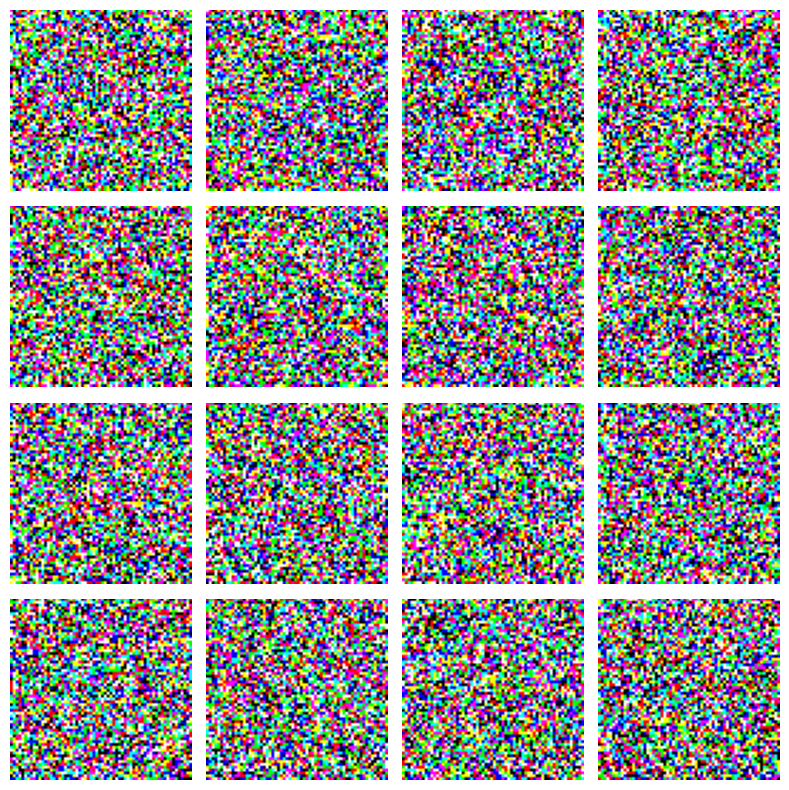

Saved 16 images → data/processed/generated


In [48]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
from PIL import Image

# # Ensure model is built (safe no-op if already built)
# dummy_img = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3))
# dummy_noise = tf.zeros((1, 1, 1, 1))
# _ = diffusion_model.network([dummy_img, dummy_noise])
# _ = diffusion_model.ema_network([dummy_img, dummy_noise])

# Generation params
num_images = 16
diffusion_steps = 50   # reduce for speed (e.g. 10), increase for quality

# Generate (values in [0,1])
generated = diffusion_model.generate(num_images, diffusion_steps)

# Output dir
out_dir = Path(PROCESSED_DIR) / "generated"
out_dir.mkdir(parents=True, exist_ok=True)

# Save individual images
for i in range(num_images):
    img_np = (generated[i].numpy() * 255).astype("uint8")
    Image.fromarray(img_np).save(out_dir / f"generated_{i:03d}.png")

# Display grid
cols = 4
rows = math.ceil(num_images / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")
for i in range(num_images):
    axes[i].imshow(generated[i])
plt.tight_layout()
plt.show()
print(f"Saved {num_images} images → {out_dir}")